<a href="https://colab.research.google.com/github/sllpwlkr/CS_8sem_lr1/blob/main/CS_lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №1

Датасет: классификация болезни листов яблонь https://www.kaggle.com/datasets/nirmalsankalana/apple-leaf-disease-dataset

Классы: Healthy, Rust, Scab (3 класса)  

Задача классификации болезней листьев яблони имеет прямое практическое применение в сельском хозяйстве. Раннее обнаружение заболеваний позволяет своевременно применить обработку, снизить потери урожая и уменьшить объём используемых пестицидов.

Метрики:
- Accuracy - общая доля правильных предсказаний.
- Macro F1-Score - среднее F1 по классам. Учитывает как precision, так и recall для каждого класса, что важно в агрономической диагностике: пропуск больного листа (низкий recall) так же критичен, как низкий precision.
- Per-class Precision / Recall - для детального анализа ошибок по каждому заболеванию.

## 1. Импорт библиотек и загрузка датасета

In [ ]:
!pip install -q kagglehub

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import train_test_split

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Устройство: cuda
GPU: Tesla T4


In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download("nirmalsankalana/apple-leaf-disease-dataset")
print("Path to dataset files:", dataset_path)

100%|██████████| 361M/361M [00:25<00:00, 15.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nirmalsankalana/apple-leaf-disease-dataset/versions/2


In [ ]:
#Определяем корневую директорию с данными.
contents = os.listdir(dataset_path)
print("Contents:", contents)

DATA_DIR = dataset_path
for item in contents:
    full = os.path.join(dataset_path, item)
    if os.path.isdir(full):
        sub = os.listdir(full)
        #Проверяем, содержит ли эта папка подпапки классов
        if any(c.lower() in ['healthy', 'rust', 'scab'] for c in sub):
            DATA_DIR = full
            break

#Если папки классов прямо в DATA_DIR
class_names_found = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
print(f"Data directory: {DATA_DIR}")
print(f"Classes found: {class_names_found}")

#Подсчет изображений в каждом классе
for cls in sorted(class_names_found):
    cls_path = os.path.join(DATA_DIR, cls)
    n = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
    print(f"  {cls}: {n} images")

Contents: ['data']
Data directory: /root/.cache/kagglehub/datasets/nirmalsankalana/apple-leaf-disease-dataset/versions/2/data
Classes found: ['rust', 'healthy', 'scab']
  healthy: 516 images
  rust: 622 images
  scab: 592 images


## Разделение на train / val / test (70/15/15)


In [ ]:
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=base_transform)
CLASS_NAMES = full_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes: {CLASS_NAMES}, total images: {len(full_dataset)}")

#Стратифицированное разбиение
targets = [s[1] for s in full_dataset.samples]
indices = list(range(len(full_dataset)))

train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=targets, random_state=SEED)
temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=temp_targets, random_state=SEED)

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

for name, idx_set in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
    cnts = Counter([targets[i] for i in idx_set])
    print(f"  {name}: {dict(sorted(cnts.items()))}")

Classes: ['healthy', 'rust', 'scab'], total images: 1730
Train: 1211, Val: 259, Test: 260
  Train: {0: 361, 1: 435, 2: 415}
  Val: {0: 78, 1: 93, 2: 88}
  Test: {0: 77, 1: 94, 2: 89}


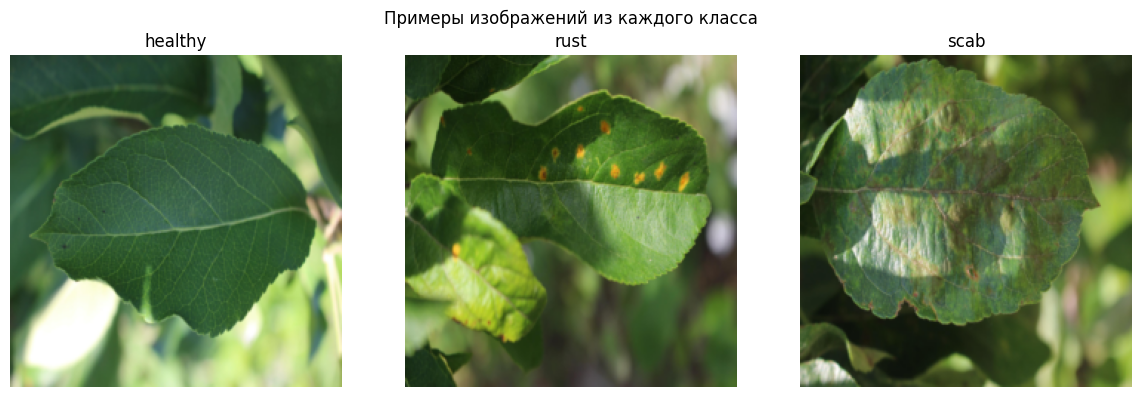

In [ ]:
#Примеры из датасета
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, cls_name in enumerate(CLASS_NAMES):
    cls_indices = [j for j in range(len(full_dataset)) if full_dataset.targets[j] == i]
    sample_idx = random.choice(cls_indices)
    img, label = full_dataset[sample_idx]
    axes[i].imshow(img.permute(1, 2, 0))
    axes[i].set_title(cls_name)
    axes[i].axis('off')
plt.suptitle('Примеры изображений из каждого класса')
plt.tight_layout()
plt.show()

## Вспомогательные функции для обучения и оценки

In [ ]:
def get_dataloaders(train_transform, val_transform, batch_size=32):

    train_ds = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
    val_ds = datasets.ImageFolder(root=DATA_DIR, transform=val_transform)
    test_ds = datasets.ImageFolder(root=DATA_DIR, transform=val_transform)
    train_loader = DataLoader(Subset(train_ds, train_idx), batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(Subset(val_ds, val_idx), batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(Subset(test_ds, test_idx), batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, val_loader, test_loader


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None, num_epochs=15, model_name='model'):

    best_val_acc = 0.0
    best_weights = None

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_loss = running_loss / total
        val_acc = correct / total

        if scheduler is not None:
            scheduler.step(val_loss)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = model.state_dict().copy()

        print(f'[{model_name}] Epoch {epoch+1}/{num_epochs} — '
              f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}')

    if best_weights is not None:
        model.load_state_dict(best_weights)
    print(f'[{model_name}] Best Val Acc: {best_val_acc:.4f}')


def evaluate_model(model, test_loader, class_names):

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images.to(DEVICE))
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    print(f'Accuracy: {acc:.4f}, Macro F1: {macro_f1:.4f}')
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    plt.show()

    return {'accuracy': acc, 'macro_f1': macro_f1}


# 2. Создание бейзлайна и оценка качества

Обучим предобученные модели из torchvision:
1. ResNet-18 - CNN
2. ViT-B/16 - трансформерная модель



In [ ]:
#Нормализация и приведение к единому размеру изображений
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

baseline_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_loader, val_loader, test_loader = get_dataloaders(
    baseline_transform, baseline_transform, batch_size=32
)

### 2.1 Бейзлайн: ResNet

In [ ]:
def create_resnet18(num_classes, freeze_backbone=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(DEVICE)


resnet_baseline = create_resnet18(NUM_CLASSES, freeze_backbone=True)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_baseline.fc.parameters(), lr=1e-3)

history_resnet_baseline = train_model(
    resnet_baseline, train_loader, val_loader, criterion, optimizer,
    num_epochs=20, model_name='ResNet-Baseline'
)



Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 145MB/s]


[ResNet-Baseline] Epoch 1/20 — Train Loss: 0.9330, Acc: 0.5673 | Val Loss: 0.6906, Acc: 0.8108
[ResNet-Baseline] Epoch 2/20 — Train Loss: 0.6193, Acc: 0.7952 | Val Loss: 0.5665, Acc: 0.8147
[ResNet-Baseline] Epoch 3/20 — Train Loss: 0.5102, Acc: 0.8225 | Val Loss: 0.4613, Acc: 0.8726
[ResNet-Baseline] Epoch 4/20 — Train Loss: 0.4439, Acc: 0.8588 | Val Loss: 0.4097, Acc: 0.8649
[ResNet-Baseline] Epoch 5/20 — Train Loss: 0.4208, Acc: 0.8613 | Val Loss: 0.3814, Acc: 0.8880
[ResNet-Baseline] Epoch 6/20 — Train Loss: 0.3837, Acc: 0.8695 | Val Loss: 0.3741, Acc: 0.8803
[ResNet-Baseline] Epoch 7/20 — Train Loss: 0.3579, Acc: 0.8671 | Val Loss: 0.3310, Acc: 0.9073
[ResNet-Baseline] Epoch 8/20 — Train Loss: 0.3354, Acc: 0.8885 | Val Loss: 0.3211, Acc: 0.9035
[ResNet-Baseline] Epoch 9/20 — Train Loss: 0.3261, Acc: 0.8927 | Val Loss: 0.3086, Acc: 0.9151
[ResNet-Baseline] Epoch 10/20 — Train Loss: 0.3293, Acc: 0.8770 | Val Loss: 0.2954, Acc: 0.9189
[ResNet-Baseline] Epoch 11/20 — Train Loss: 0.299

ResNet Бейзлайн
Accuracy: 0.9077, Macro F1: 0.9063
              precision    recall  f1-score   support

     healthy       0.83      0.91      0.87        77
        rust       0.96      0.90      0.93        94
        scab       0.93      0.91      0.92        89

    accuracy                           0.91       260
   macro avg       0.91      0.91      0.91       260
weighted avg       0.91      0.91      0.91       260



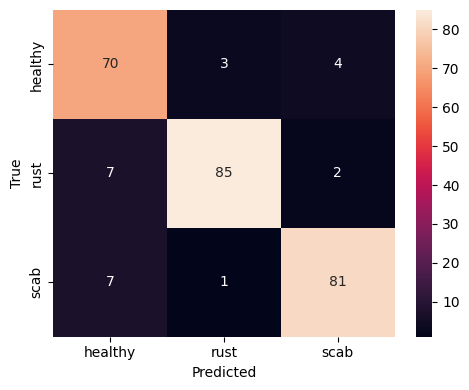

In [ ]:
print('ResNet Бейзлайн')
metrics_resnet_baseline = evaluate_model(resnet_baseline, test_loader, CLASS_NAMES)

### 2.2 Бейзлайн: ViT-B/16

In [ ]:
def create_vit_b16(num_classes, freeze_backbone=True):
    model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    return model.to(DEVICE)


vit_baseline = create_vit_b16(NUM_CLASSES, freeze_backbone=True)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vit_baseline.heads.head.parameters(), lr=1e-3)

history_vit_baseline = train_model(
    vit_baseline, train_loader, val_loader, criterion, optimizer,
    num_epochs=20, model_name='ViT-B/16-Baseline'
)



Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 166MB/s]


[ViT-B/16-Baseline] Epoch 1/20 — Train Loss: 0.7345, Acc: 0.7110 | Val Loss: 0.4845, Acc: 0.8378
[ViT-B/16-Baseline] Epoch 2/20 — Train Loss: 0.4228, Acc: 0.8695 | Val Loss: 0.3651, Acc: 0.8842
[ViT-B/16-Baseline] Epoch 3/20 — Train Loss: 0.3324, Acc: 0.9042 | Val Loss: 0.3027, Acc: 0.9151
[ViT-B/16-Baseline] Epoch 4/20 — Train Loss: 0.2861, Acc: 0.9191 | Val Loss: 0.2735, Acc: 0.9228
[ViT-B/16-Baseline] Epoch 5/20 — Train Loss: 0.2529, Acc: 0.9232 | Val Loss: 0.2452, Acc: 0.9266
[ViT-B/16-Baseline] Epoch 6/20 — Train Loss: 0.2261, Acc: 0.9339 | Val Loss: 0.2193, Acc: 0.9344
[ViT-B/16-Baseline] Epoch 7/20 — Train Loss: 0.2041, Acc: 0.9430 | Val Loss: 0.2079, Acc: 0.9344
[ViT-B/16-Baseline] Epoch 8/20 — Train Loss: 0.1880, Acc: 0.9430 | Val Loss: 0.1986, Acc: 0.9421
[ViT-B/16-Baseline] Epoch 9/20 — Train Loss: 0.1775, Acc: 0.9496 | Val Loss: 0.1834, Acc: 0.9421
[ViT-B/16-Baseline] Epoch 10/20 — Train Loss: 0.1682, Acc: 0.9554 | Val Loss: 0.1811, Acc: 0.9421
[ViT-B/16-Baseline] Epoch 11/

ViT-B/16 Бейзлайн
Accuracy: 0.9423, Macro F1: 0.9412
              precision    recall  f1-score   support

     healthy       0.90      0.95      0.92        77
        rust       0.99      0.96      0.97        94
        scab       0.93      0.92      0.93        89

    accuracy                           0.94       260
   macro avg       0.94      0.94      0.94       260
weighted avg       0.94      0.94      0.94       260



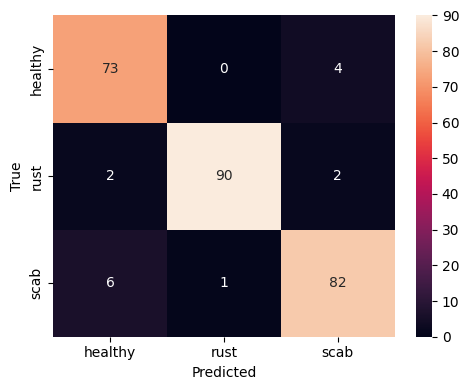

In [ ]:
print('ViT-B/16 Бейзлайн')
metrics_vit_baseline = evaluate_model(vit_baseline, test_loader, CLASS_NAMES)

### 2.3 Сводка результатов бейзлайна

In [ ]:
import pandas as pd

baseline_results = pd.DataFrame({
    'Model': ['ResNet-18 (Бейзлайн)', 'ViT-B/16 (Бейзлайн)'],
    'Accuracy': [metrics_resnet_baseline['accuracy'], metrics_vit_baseline['accuracy']],
    'Macro F1': [metrics_resnet_baseline['macro_f1'], metrics_vit_baseline['macro_f1']],
})

print(baseline_results.to_string(index=False))

               Model  Accuracy  Macro F1
ResNet-18 (Бейзлайн)  0.907692  0.906327
 ViT-B/16 (Бейзлайн)  0.942308  0.941192


# 3. Улучшение бейзлайна

## Гипотезы для улучшения:

1. Добавление случайных поворотов, отражений, изменений яркости/контраста, CutOut. Это должно повысить обобщающую способность моделей и снизить переобучение

2. Разморозка всех слоёв модели с низким learning rate для backbone и более высоким для классификационной головы

3. Использование ReduceLROnPlateau для автоматического снижения lr при замедлении изменения валидационного лосса.


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

#Аугментации для предобученных моделей
improved_train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

#Лёгкие аугментации для кастомных моделей
light_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

improved_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_loader_imp, val_loader_imp, test_loader_imp = get_dataloaders(
    improved_train_transform, improved_val_transform, batch_size=32
)
train_loader_light, val_loader_light, test_loader_light = get_dataloaders(
    light_train_transform, improved_val_transform, batch_size=32
)


### 3.1 Улучшенный ResNet-18

In [ ]:
#ResNet с разморозкой и дифференциальным lr
resnet_improved = create_resnet18(NUM_CLASSES, freeze_backbone=False)

#backbone - маленький lr, голова - побольше
backbone_params = [p for n, p in resnet_improved.named_parameters() if 'fc' not in n]
head_params = resnet_improved.fc.parameters()

optimizer = optim.Adam([
    {'params': backbone_params, 'lr': 1e-4},
    {'params': head_params, 'lr': 1e-3},
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
criterion = nn.CrossEntropyLoss()

history_resnet_improved = train_model(
    resnet_improved, train_loader_imp, val_loader_imp, criterion, optimizer,
    scheduler=scheduler, num_epochs=20, model_name='ResNet18-Improved'
)


[ResNet18-Improved] Epoch 1/20 — Train Loss: 0.3688, Acc: 0.8448 | Val Loss: 0.1077, Acc: 0.9653
[ResNet18-Improved] Epoch 2/20 — Train Loss: 0.1078, Acc: 0.9661 | Val Loss: 0.0799, Acc: 0.9846
[ResNet18-Improved] Epoch 3/20 — Train Loss: 0.0514, Acc: 0.9827 | Val Loss: 0.0950, Acc: 0.9614
[ResNet18-Improved] Epoch 4/20 — Train Loss: 0.0526, Acc: 0.9835 | Val Loss: 0.0851, Acc: 0.9730
[ResNet18-Improved] Epoch 5/20 — Train Loss: 0.0477, Acc: 0.9810 | Val Loss: 0.1487, Acc: 0.9653
[ResNet18-Improved] Epoch 6/20 — Train Loss: 0.0460, Acc: 0.9860 | Val Loss: 0.1135, Acc: 0.9691
[ResNet18-Improved] Epoch 7/20 — Train Loss: 0.0184, Acc: 0.9942 | Val Loss: 0.1031, Acc: 0.9807
[ResNet18-Improved] Epoch 8/20 — Train Loss: 0.0152, Acc: 0.9959 | Val Loss: 0.1111, Acc: 0.9730
[ResNet18-Improved] Epoch 9/20 — Train Loss: 0.0084, Acc: 0.9983 | Val Loss: 0.0724, Acc: 0.9768
[ResNet18-Improved] Epoch 10/20 — Train Loss: 0.0140, Acc: 0.9975 | Val Loss: 0.0886, Acc: 0.9807
[ResNet18-Improved] Epoch 11/

ResNet Улучшенная
Accuracy: 0.9885, Macro F1: 0.9880
              precision    recall  f1-score   support

     healthy       0.97      0.99      0.98        77
        rust       1.00      0.99      0.99        94
        scab       0.99      0.99      0.99        89

    accuracy                           0.99       260
   macro avg       0.99      0.99      0.99       260
weighted avg       0.99      0.99      0.99       260



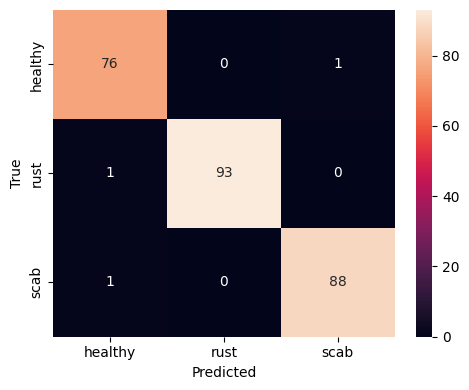

In [ ]:
print('ResNet Улучшенная')
metrics_resnet_improved = evaluate_model(resnet_improved, test_loader_imp, CLASS_NAMES)

### 3.2 Улучшенный ViT-B/16

In [ ]:
vit_improved = create_vit_b16(NUM_CLASSES, freeze_backbone=False)

backbone_params = [p for n, p in vit_improved.named_parameters() if 'heads' not in n]
head_params = vit_improved.heads.head.parameters()

optimizer = optim.Adam([
    {'params': backbone_params, 'lr': 1e-5},
    {'params': head_params, 'lr': 1e-3},
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
criterion = nn.CrossEntropyLoss()

history_vit_improved = train_model(
    vit_improved, train_loader_imp, val_loader_imp, criterion, optimizer,
    scheduler=scheduler, num_epochs=20, model_name='ViT-B/16-Improved'
)


[ViT-B/16-Improved] Epoch 1/20 — Train Loss: 0.3764, Acc: 0.8497 | Val Loss: 0.0694, Acc: 0.9691
[ViT-B/16-Improved] Epoch 2/20 — Train Loss: 0.0737, Acc: 0.9744 | Val Loss: 0.0439, Acc: 0.9846
[ViT-B/16-Improved] Epoch 3/20 — Train Loss: 0.0479, Acc: 0.9868 | Val Loss: 0.0442, Acc: 0.9768
[ViT-B/16-Improved] Epoch 4/20 — Train Loss: 0.0351, Acc: 0.9876 | Val Loss: 0.0374, Acc: 0.9846
[ViT-B/16-Improved] Epoch 5/20 — Train Loss: 0.0284, Acc: 0.9909 | Val Loss: 0.0189, Acc: 0.9961
[ViT-B/16-Improved] Epoch 6/20 — Train Loss: 0.0112, Acc: 0.9975 | Val Loss: 0.0298, Acc: 0.9884
[ViT-B/16-Improved] Epoch 7/20 — Train Loss: 0.0078, Acc: 0.9983 | Val Loss: 0.0209, Acc: 0.9884
[ViT-B/16-Improved] Epoch 8/20 — Train Loss: 0.0337, Acc: 0.9901 | Val Loss: 0.0260, Acc: 0.9846
[ViT-B/16-Improved] Epoch 9/20 — Train Loss: 0.0300, Acc: 0.9934 | Val Loss: 0.0898, Acc: 0.9653
[ViT-B/16-Improved] Epoch 10/20 — Train Loss: 0.0099, Acc: 0.9959 | Val Loss: 0.0439, Acc: 0.9846
[ViT-B/16-Improved] Epoch 11/

ViT-B/16 Улучшенная
Accuracy: 0.9846, Macro F1: 0.9840
              precision    recall  f1-score   support

     healthy       0.97      0.97      0.97        77
        rust       1.00      0.99      0.99        94
        scab       0.98      0.99      0.98        89

    accuracy                           0.98       260
   macro avg       0.98      0.98      0.98       260
weighted avg       0.98      0.98      0.98       260



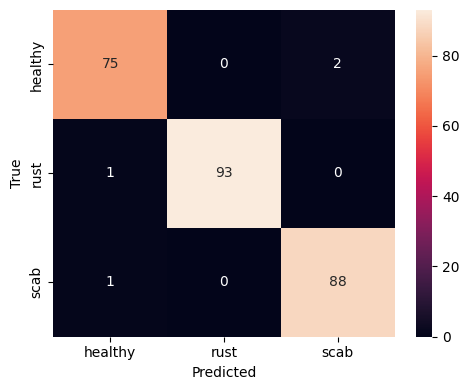

In [ ]:
print('ViT-B/16 Улучшенная')
metrics_vit_improved = evaluate_model(vit_improved, test_loader_imp, CLASS_NAMES)

### 3.3 Сравнение бейзлайна и улучшенного бейзлайна

                Model  Accuracy  Macro F1
    ResNet (Бейзлайн)  0.907692  0.906327
  ResNet (Улучшенная)  0.988462  0.988021
  ViT-B/16 (Бейзлайн)  0.942308  0.941192
ViT-B/16 (Улучшенная)  0.984615  0.983973


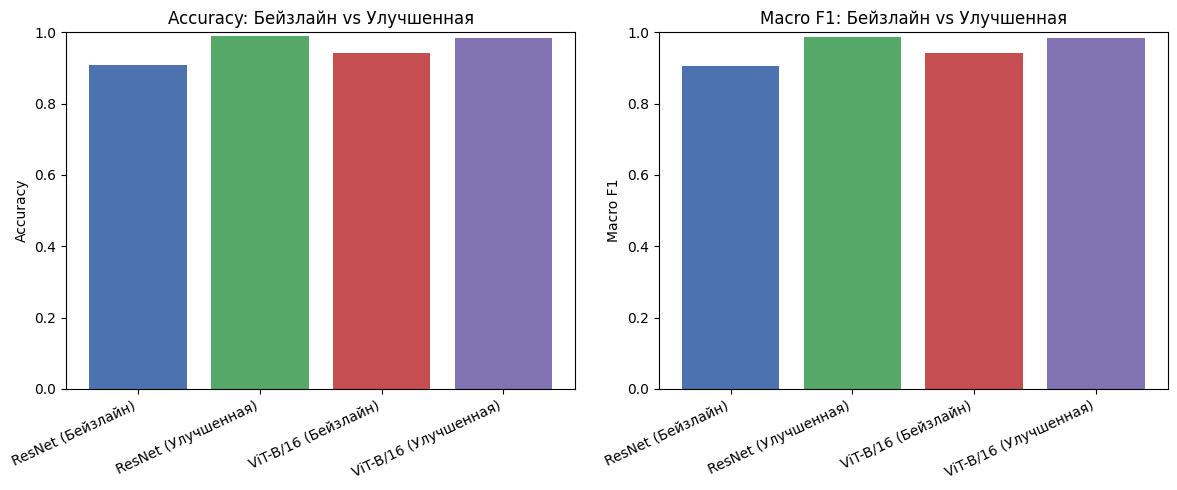

In [ ]:
comparison_df = pd.DataFrame({
    'Model': [
        'ResNet (Бейзлайн)', 'ResNet (Улучшенная)',
        'ViT-B/16 (Бейзлайн)', 'ViT-B/16 (Улучшенная)',
    ],
    'Accuracy': [
        metrics_resnet_baseline['accuracy'], metrics_resnet_improved['accuracy'],
        metrics_vit_baseline['accuracy'], metrics_vit_improved['accuracy'],
    ],
    'Macro F1': [
        metrics_resnet_baseline['macro_f1'], metrics_resnet_improved['macro_f1'],
        metrics_vit_baseline['macro_f1'], metrics_vit_improved['macro_f1'],
    ],
})
print(comparison_df.to_string(index=False))

#Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
x = range(len(comparison_df))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

ax1.bar(x, comparison_df['Accuracy'], color=colors)
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_df['Model'], rotation=25, ha='right')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy: Бейзлайн vs Улучшенная')
ax1.set_ylim(0, 1)

ax2.bar(x, comparison_df['Macro F1'], color=colors)
ax2.set_xticks(x)
ax2.set_xticklabels(comparison_df['Model'], rotation=25, ha='right')
ax2.set_ylabel('Macro F1')
ax2.set_title('Macro F1: Бейзлайн vs Улучшенная')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

Улучшенные модели значительно превзошли бейзлайн благодаря разморозке backbone, аугментациям данных и использованию Scheduler ReduceLROnPlateau. ResNet показал наибольший прирост(с 90.8% до 98.9%), поскольку у него было больше пространства для улучшения по сравнению с ViT(с 94.2% до 98.5%), который и в бейзлайне давал более высокий результат.

# 4. Имплементация алгоритма машинного обучения


### 4.1 Имплементация SimpleCNN

In [ ]:
class SimpleCNN(nn.Module):

    def __init__(self, num_classes=3):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):

        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


simple_cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in simple_cnn.parameters())
print(f'SimpleCNN — всего параметров: {total_params:,}')


SimpleCNN — всего параметров: 422,659


### 4.2 Имплементация SimpleViT

In [ ]:
class PatchEmbedding(nn.Module):

    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=256):

        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):

        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x


class SimpleViT(nn.Module):

    def __init__(self, img_size=224, patch_size=16, in_channels=3, num_classes=3,
                 embed_dim=256, depth=6, num_heads=8, mlp_ratio=2.0, dropout=0.1):
        super().__init__()

        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim) * 0.02)
        self.pos_drop = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):

        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embed
        x = self.pos_drop(x)
        x = self.transformer(x)
        x = self.norm(x[:, 0])
        x = self.head(x)
        return x


simple_vit = SimpleViT(num_classes=NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in simple_vit.parameters())
print(f'SimpleViT — всего параметров: {total_params:,}')


SimpleViT — всего параметров: 3,411,459


/tmp/ipykernel_2787/1518973896.py:97: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


### 4.3 Обучение собственных моделей

In [ ]:
simple_cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(simple_cnn.parameters(), lr=1e-3)

history_simplecnn = train_model(
    simple_cnn, train_loader, val_loader, criterion, optimizer,
    num_epochs=15, model_name='SimpleCNN'
)


[SimpleCNN] Epoch 1/15 — Train Loss: 1.0833, Acc: 0.4055 | Val Loss: 1.0340, Acc: 0.4595
[SimpleCNN] Epoch 2/15 — Train Loss: 1.0387, Acc: 0.4525 | Val Loss: 1.0402, Acc: 0.4286
[SimpleCNN] Epoch 3/15 — Train Loss: 1.0271, Acc: 0.4789 | Val Loss: 1.0095, Acc: 0.4556
[SimpleCNN] Epoch 4/15 — Train Loss: 0.9990, Acc: 0.5037 | Val Loss: 1.0764, Acc: 0.4749
[SimpleCNN] Epoch 5/15 — Train Loss: 0.9606, Acc: 0.5318 | Val Loss: 0.9804, Acc: 0.5444
[SimpleCNN] Epoch 6/15 — Train Loss: 0.8415, Acc: 0.6301 | Val Loss: 0.7819, Acc: 0.7181
[SimpleCNN] Epoch 7/15 — Train Loss: 0.6804, Acc: 0.7176 | Val Loss: 0.7717, Acc: 0.6641
[SimpleCNN] Epoch 8/15 — Train Loss: 0.5485, Acc: 0.7770 | Val Loss: 0.5181, Acc: 0.7876
[SimpleCNN] Epoch 9/15 — Train Loss: 0.5668, Acc: 0.7812 | Val Loss: 0.5091, Acc: 0.7954
[SimpleCNN] Epoch 10/15 — Train Loss: 0.4758, Acc: 0.8059 | Val Loss: 0.5437, Acc: 0.7722
[SimpleCNN] Epoch 11/15 — Train Loss: 0.4229, Acc: 0.8357 | Val Loss: 0.4813, Acc: 0.7915
[SimpleCNN] Epoch 1

SimpleCNN
Accuracy: 0.8808, Macro F1: 0.8768
              precision    recall  f1-score   support

     healthy       0.77      0.87      0.82        77
        rust       0.97      0.97      0.97        94
        scab       0.90      0.80      0.85        89

    accuracy                           0.88       260
   macro avg       0.88      0.88      0.88       260
weighted avg       0.89      0.88      0.88       260



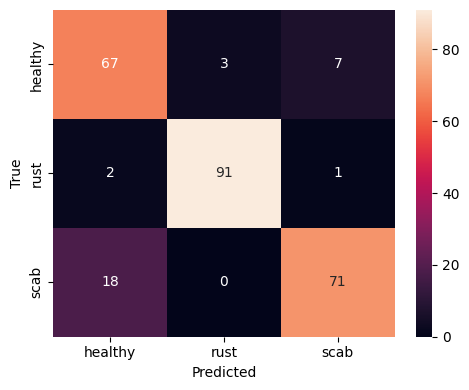

In [ ]:
print('SimpleCNN')
metrics_simplecnn = evaluate_model(simple_cnn, test_loader, CLASS_NAMES)

In [ ]:
simple_vit = SimpleViT(num_classes=NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(simple_vit.parameters(), lr=3e-4)

history_simplevit = train_model(
    simple_vit, train_loader, val_loader, criterion, optimizer,
    num_epochs=20, model_name='SimpleViT'
)


/tmp/ipykernel_2787/1518973896.py:97: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


[SimpleViT] Epoch 1/20 — Train Loss: 1.1686, Acc: 0.3600 | Val Loss: 1.1547, Acc: 0.3012
[SimpleViT] Epoch 2/20 — Train Loss: 1.0859, Acc: 0.3848 | Val Loss: 1.0675, Acc: 0.3822
[SimpleViT] Epoch 3/20 — Train Loss: 1.0664, Acc: 0.3997 | Val Loss: 1.0647, Acc: 0.3822
[SimpleViT] Epoch 4/20 — Train Loss: 1.0816, Acc: 0.4005 | Val Loss: 1.0636, Acc: 0.4247
[SimpleViT] Epoch 5/20 — Train Loss: 1.0512, Acc: 0.4467 | Val Loss: 1.0542, Acc: 0.4015
[SimpleViT] Epoch 6/20 — Train Loss: 1.0422, Acc: 0.4410 | Val Loss: 1.0476, Acc: 0.4479
[SimpleViT] Epoch 7/20 — Train Loss: 1.0292, Acc: 0.4525 | Val Loss: 1.1148, Acc: 0.3861
[SimpleViT] Epoch 8/20 — Train Loss: 1.0533, Acc: 0.4154 | Val Loss: 1.0539, Acc: 0.4015
[SimpleViT] Epoch 9/20 — Train Loss: 1.0263, Acc: 0.4814 | Val Loss: 1.0605, Acc: 0.4131
[SimpleViT] Epoch 10/20 — Train Loss: 1.0030, Acc: 0.4880 | Val Loss: 1.0171, Acc: 0.4788
[SimpleViT] Epoch 11/20 — Train Loss: 0.9959, Acc: 0.4855 | Val Loss: 1.1721, Acc: 0.4131
[SimpleViT] Epoch 1

SimpleViT
Accuracy: 0.5577, Macro F1: 0.5495
              precision    recall  f1-score   support

     healthy       0.61      0.47      0.53        77
        rust       0.71      0.41      0.52        94
        scab       0.48      0.79      0.60        89

    accuracy                           0.56       260
   macro avg       0.60      0.56      0.55       260
weighted avg       0.60      0.56      0.55       260



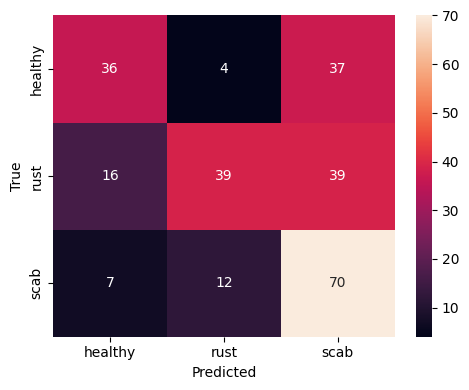

In [ ]:
print('SimpleViT')
metrics_simplevit = evaluate_model(simple_vit, test_loader, CLASS_NAMES)

### 4.4 Сравнение собственных моделей с бейзлайном

In [ ]:
custom_vs_baseline = pd.DataFrame({
    'Model': [
        'ResNet-18 (Бейзлайн)', 'ViT-B/16 (Бейзлайн)',
        'SimpleCNN (Кастомная)', 'SimpleViT (Кастомная)',
    ],
    'Accuracy': [
        metrics_resnet_baseline['accuracy'], metrics_vit_baseline['accuracy'],
        metrics_simplecnn['accuracy'], metrics_simplevit['accuracy'],
    ],
    'Macro F1': [
        metrics_resnet_baseline['macro_f1'], metrics_vit_baseline['macro_f1'],
        metrics_simplecnn['macro_f1'], metrics_simplevit['macro_f1'],
    ],
})
print('Сравнение кастомной и бейзлайн моделейй ')
print(custom_vs_baseline.to_string(index=False))

Сравнение кастомной и бейзлайн моделейй 
                Model  Accuracy  Macro F1
 ResNet-18 (Бейзлайн)  0.907692  0.906327
  ViT-B/16 (Бейзлайн)  0.942308  0.941192
SimpleCNN (Кастомная)  0.880769  0.876799
SimpleViT (Кастомная)  0.557692  0.549549


### 4.5 Выводы по собственным моделям

Кастомные модели, обученные с нуля без предобученных весов, ожидаемо показывают более низкие результаты по сравнению с моделями torchvision, использующими transfer learning с ImageNet. Предобученные модели уже обладают сильными визуальными признаками, а используемый датасет мал для обучения глубоких сетей с нуля. Разрыв между SimpleCNN и SimpleViT (88.1% vs 55.8%) при одинаковом датасете наглядно иллюстрирует ключевое преимущество CNN-архитектур на малых данных

### 4.6 Обучение собственных моделей с улучшенным бейзлайном


In [ ]:
simple_cnn_imp = SimpleCNN(NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(simple_cnn_imp.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

history_simplecnn_imp = train_model(
    simple_cnn_imp, train_loader_light, val_loader_light, criterion, optimizer,
    scheduler=scheduler, num_epochs=20, model_name='SimpleCNN-LightAug'
)


[SimpleCNN-LightAug] Epoch 1/20 — Train Loss: 1.0926, Acc: 0.3964 | Val Loss: 1.0381, Acc: 0.4633
[SimpleCNN-LightAug] Epoch 2/20 — Train Loss: 1.0368, Acc: 0.4550 | Val Loss: 1.0353, Acc: 0.4633
[SimpleCNN-LightAug] Epoch 3/20 — Train Loss: 1.0033, Acc: 0.4971 | Val Loss: 1.0569, Acc: 0.4942
[SimpleCNN-LightAug] Epoch 4/20 — Train Loss: 0.9212, Acc: 0.5648 | Val Loss: 0.9911, Acc: 0.5058
[SimpleCNN-LightAug] Epoch 5/20 — Train Loss: 0.7459, Acc: 0.6813 | Val Loss: 0.6943, Acc: 0.6718
[SimpleCNN-LightAug] Epoch 6/20 — Train Loss: 0.6568, Acc: 0.7291 | Val Loss: 0.7211, Acc: 0.6911
[SimpleCNN-LightAug] Epoch 7/20 — Train Loss: 0.6325, Acc: 0.7217 | Val Loss: 0.6267, Acc: 0.7181
[SimpleCNN-LightAug] Epoch 8/20 — Train Loss: 0.5375, Acc: 0.7853 | Val Loss: 0.5045, Acc: 0.7838
[SimpleCNN-LightAug] Epoch 9/20 — Train Loss: 0.4992, Acc: 0.7878 | Val Loss: 0.5120, Acc: 0.7606
[SimpleCNN-LightAug] Epoch 10/20 — Train Loss: 0.5062, Acc: 0.8018 | Val Loss: 0.5761, Acc: 0.7490
[SimpleCNN-LightAug

SimpleCNN Улучшенная
Accuracy: 0.9385, Macro F1: 0.9358
              precision    recall  f1-score   support

     healthy       0.84      0.99      0.91        77
        rust       0.99      1.00      0.99        94
        scab       0.99      0.83      0.90        89

    accuracy                           0.94       260
   macro avg       0.94      0.94      0.94       260
weighted avg       0.95      0.94      0.94       260



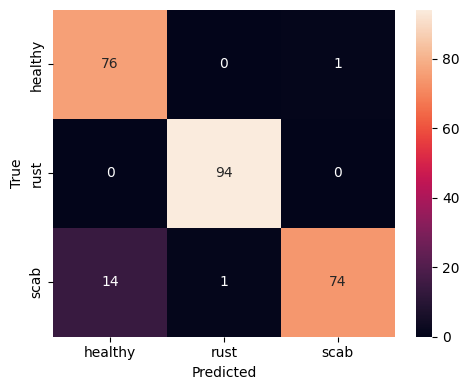

In [ ]:
print('SimpleCNN Улучшенная')
metrics_simplecnn_imp = evaluate_model(simple_cnn_imp, test_loader_imp, CLASS_NAMES)

In [ ]:
# Лёгкие аугментации для SimpleViT (train_loader_light).
# SimpleViT особенно чувствителен к искажениям: self-attention учится
# из данных и не имеет встроенного inductive bias, как CNN.
simple_vit_imp = SimpleViT(num_classes=NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(simple_vit_imp.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

history_simplevit_imp = train_model(
    simple_vit_imp, train_loader_light, val_loader_light, criterion, optimizer,
    scheduler=scheduler, num_epochs=20, model_name='SimpleViT-LightAug'
)


/tmp/ipykernel_2787/1518973896.py:97: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


[SimpleViT-LightAug] Epoch 1/20 — Train Loss: 1.1594, Acc: 0.3559 | Val Loss: 1.1340, Acc: 0.3745
[SimpleViT-LightAug] Epoch 2/20 — Train Loss: 1.0937, Acc: 0.4005 | Val Loss: 1.0901, Acc: 0.4286
[SimpleViT-LightAug] Epoch 3/20 — Train Loss: 1.0836, Acc: 0.3972 | Val Loss: 1.0637, Acc: 0.4286
[SimpleViT-LightAug] Epoch 4/20 — Train Loss: 1.0784, Acc: 0.3906 | Val Loss: 1.0750, Acc: 0.3900
[SimpleViT-LightAug] Epoch 5/20 — Train Loss: 1.0445, Acc: 0.4509 | Val Loss: 1.0532, Acc: 0.4247
[SimpleViT-LightAug] Epoch 6/20 — Train Loss: 1.0549, Acc: 0.4418 | Val Loss: 1.0429, Acc: 0.4440
[SimpleViT-LightAug] Epoch 7/20 — Train Loss: 1.0465, Acc: 0.4426 | Val Loss: 1.0434, Acc: 0.4093
[SimpleViT-LightAug] Epoch 8/20 — Train Loss: 1.0392, Acc: 0.4302 | Val Loss: 1.0548, Acc: 0.4054
[SimpleViT-LightAug] Epoch 9/20 — Train Loss: 1.0191, Acc: 0.4657 | Val Loss: 1.0324, Acc: 0.4903
[SimpleViT-LightAug] Epoch 10/20 — Train Loss: 1.0132, Acc: 0.5054 | Val Loss: 1.0812, Acc: 0.3938
[SimpleViT-LightAug

SimpleViT Улучшенная
Accuracy: 0.5154, Macro F1: 0.5083
              precision    recall  f1-score   support

     healthy       0.42      0.49      0.45        77
        rust       0.70      0.37      0.49        94
        scab       0.51      0.69      0.59        89

    accuracy                           0.52       260
   macro avg       0.54      0.52      0.51       260
weighted avg       0.55      0.52      0.51       260



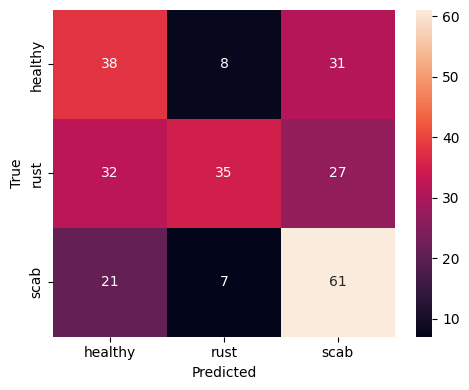

In [ ]:
print('SimpleViT Улучшенная')
metrics_simplevit_imp = evaluate_model(simple_vit_imp, test_loader_imp, CLASS_NAMES)

Предобученные модели уже обладают мощными визуальными признаками. Для них аугментации становятся полезными ограничениями. Модели с нуля не могут выучить базовые паттерны на сильно искажённых данных. Лёгкие аугментации значительно помогли SimpleCNN: accuracy выросла с 88.1% до 93.8%. Для SimpleViT лёгкие аугментации дали минимальный эффект Трансформерные модели требуют значительно больше данных для обучения.
Кастомные модели были вынуждены одновременно и выучивать базовые паттерны, и работать с искажёнными данными.


In [ ]:
custom_imp_vs_improved = pd.DataFrame({
    'Model': [
        'ResNet(Улучшенная)', 'ViT-B/16 (Улучшенная)',
        'SimpleCNN', 'SimpleCNN (Улучшенная)',
        'SimpleViT', 'SimpleViT (Улучшенная)',
    ],
    'Accuracy': [
        metrics_resnet_improved['accuracy'], metrics_vit_improved['accuracy'],
        metrics_simplecnn['accuracy'], metrics_simplecnn_imp['accuracy'],
        metrics_simplevit['accuracy'], metrics_simplevit_imp['accuracy'],
    ],
    'Macro F1': [
        metrics_resnet_improved['macro_f1'], metrics_vit_improved['macro_f1'],
        metrics_simplecnn['macro_f1'], metrics_simplecnn_imp['macro_f1'],
        metrics_simplevit['macro_f1'], metrics_simplevit_imp['macro_f1'],
    ],
})

print(custom_imp_vs_improved.to_string(index=False))

                 Model  Accuracy  Macro F1
    ResNet(Улучшенная)  0.988462  0.988021
 ViT-B/16 (Улучшенная)  0.984615  0.983973
             SimpleCNN  0.880769  0.876799
SimpleCNN (Улучшенная)  0.938462  0.935776
             SimpleViT  0.557692  0.549549
SimpleViT (Улучшенная)  0.515385  0.508344



# Итоговая сводка всех экспериментов

                 Model  Accuracy  Macro F1
     ResNet (Бейзлайн)  0.907692  0.906327
   ResNet (Улучшенная)  0.988462  0.988021
  SimpleCNN (Бейзлайн)  0.880769  0.876799
SimpleCNN (Улучшенная)  0.938462  0.935776
   ViT-B/16 (Бейзлайн)  0.942308  0.941192
 ViT-B/16 (Улучшенная)  0.984615  0.983973
  SimpleViT (Бейзлайн)  0.557692  0.549549
SimpleViT (Улучшенная)  0.515385  0.508344


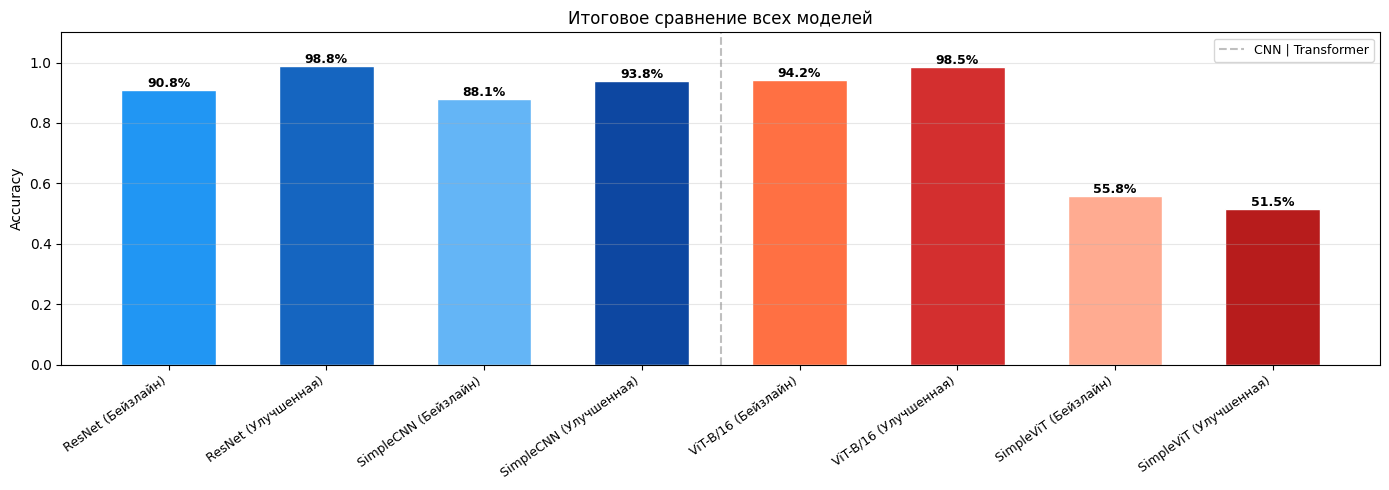

In [ ]:
final_df = pd.DataFrame({
    'Model': [
        'ResNet (Бейзлайн)', 'ResNet (Улучшенная)',
        'SimpleCNN (Бейзлайн)', 'SimpleCNN (Улучшенная)',
        'ViT-B/16 (Бейзлайн)', 'ViT-B/16 (Улучшенная)',
        'SimpleViT (Бейзлайн)', 'SimpleViT (Улучшенная)',
    ],
    'Accuracy': [
        metrics_resnet_baseline['accuracy'], metrics_resnet_improved['accuracy'],
        metrics_simplecnn['accuracy'], metrics_simplecnn_imp['accuracy'],
        metrics_vit_baseline['accuracy'], metrics_vit_improved['accuracy'],
        metrics_simplevit['accuracy'], metrics_simplevit_imp['accuracy'],
    ],
    'Macro F1': [
        metrics_resnet_baseline['macro_f1'], metrics_resnet_improved['macro_f1'],
        metrics_simplecnn['macro_f1'], metrics_simplecnn_imp['macro_f1'],
        metrics_vit_baseline['macro_f1'], metrics_vit_improved['macro_f1'],
        metrics_simplevit['macro_f1'], metrics_simplevit_imp['macro_f1'],
    ],
})

print(final_df.to_string(index=False))
print('='*60)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(final_df))
width = 0.35

colors = [
    '#2196F3', '#1565C0',
    '#64B5F6', '#0D47A1',
    '#FF7043', '#D32F2F',
    '#FFAB91', '#B71C1C',
]

bars = ax.bar(x, final_df['Accuracy'], width=0.6, color=colors, edgecolor='white')

for i, v in enumerate(final_df['Accuracy']):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(final_df['Model'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
ax.set_title('Итоговое сравнение всех моделей')
ax.axvline(x=3.5, color='gray', linestyle='--', alpha=0.5, label='CNN | Transformer')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Выводы

Предобученные модели из torchvision с замороженным backbone показали высокое качество. ViT превзошёл ResNet благодаря большей ёмкости трансформерной архитектуры. Гипотезы улучшения повлияли на обе модели. Их качество классификации повысилось.

Кастомные модели, обученные с нуля, ожидаемо уступают предобученным. SimpleCNN показала результат, сопоставимый с бейзлайном ResNet, а SimpleViT оказался близок к случайному угадыванию. Трансформерам требуется значительно больше данных для обучения self-attention с нуля.

Аугментации оказали противоположный эффект на кастомные и скачанные модели. Для готовых они служат регуляризацией поверх готовых признаков, тогда как кастомным моделям сначала нужно выучить сами признаки.